# Condensate free-field cross-check (Eqs. 1.23 PS, 1.55 FS)
Stochastic (`jj_corr_dilute`, free $U=1$, `h0/condensate/*`, jackknife over hits) vs the DENSE exact
reference (`condensate_deter_free`, complete unit-source basis).  Three bilinears `etadag_xi`,
`xidag_eta`, `xidag_1mDdag_eta` (area-weighted spacetime-summed traces); then
$\sigma_{PS}=$`etadag_xi`$+$`xidag_eta`, $\sigma_{FS}=$`etadag_xi`$-$`xidag_1mDdag_eta`; spacetime-average
by $/V_{st}$, $V_{st}=N_t\sum_n A_n$.  Run `tmp_condensate_deter_claude.sh` first.

In [37]:
import numpy as np
import h5py
import glob
import matplotlib.pyplot as plt

# ----- mass switch: 'massless' | 'mF' (m=0.1 real) | 'mP' (m=0.1i imag).  Only ESN changes per mass;
#       both the dense ref (condensate_deter_L1) and the stoch run exist under each. -----
MASS  = 'mP'
_ESN  = {'massless':'data_free_vmRe0.000000vmIm0.000000/',
         'mF':      'data_free_vmRe0.100000vmIm0.000000/',
         'mP':      'data_free_vmRe0.000000vmIm0.100000/'}
ESN   = _ESN[MASS]
DENSE = ESN + 'condensate_deter_L1/cond.h5'
STOCH = ESN + 'corr_dil_nt02_nhits140_s1td2/'  # 140-hit validation run (spin x e/o-time dilution)
KEYS  = ['etadag_xi', 'xidag_eta', 'xidag_1mDdag_eta']
print('MASS=%s  ESN=%s' % (MASS, ESN))

MASS=mP  ESN=data_free_vmRe0.000000vmIm0.100000/


In [38]:
# ----- mass labels: title tag ($m=...$) + savefig filename tag (keyed by MASS) -----
_MLAB = {'massless':'m0', 'mF':'m0.1', 'mP':'m0.1i'}; MLAB = _MLAB[MASS]
_MTIT = {'massless':'0',  'mF':'0.1',  'mP':'0.1i'};  MTIT = _MTIT[MASS]
# ----- all figures saved under figs/ -----
import os
FIGDIR = 'figs'; os.makedirs(FIGDIR, exist_ok=True)

In [39]:
# ----- dense exact reference -----
with h5py.File(DENSE, 'r') as f:
    Vst = f['Vst'][()][0]
    dense = {k: f['condensate/'+k+'/real'][()][0] + 1j*f['condensate/'+k+'/imag'][()][0] for k in KEYS}
dense['sigma_PS'] = dense['etadag_xi'] + dense['xidag_eta']
dense['sigma_FS'] = dense['etadag_xi'] - dense['xidag_1mDdag_eta']
print('Vst =', Vst)
for k in KEYS + ['sigma_PS', 'sigma_FS']:
    print('%-18s dense avg = % .6e %+.6ej' % (k, (dense[k]/Vst).real, (dense[k]/Vst).imag))

Vst = 1608.4954386379736
etadag_xi          dense avg = -9.991595e-01 +3.895039e-02j
xidag_eta          dense avg = -9.969455e-01 +6.096556e-02j
xidag_1mDdag_eta   dense avg =  9.990960e-01 -3.894404e-02j
sigma_PS           dense avg = -1.996105e+00 +9.991595e-02j
sigma_FS           dense avg = -1.998256e+00 +7.789443e-02j


In [40]:
# ----- stochastic per-hit (complete-gated), jackknife over hits -----
def stoch_hits(key):
    out = []
    for fn in sorted(glob.glob(STOCH + 'corr.0.h*.h5')):
        with h5py.File(fn, 'r') as h:
            if 'complete' not in h:
                continue
            kk = 'h0/condensate/' + key
            out.append(h[kk + '/real'][()][0] + 1j*h[kk + '/imag'][()][0])
    return np.array(out)

def jk_complex(a):                 # (mean, err_re, err_im) over hits
    H = len(a)
    s = a.sum()
    samp = np.array([(s - a[i])/(H - 1) for i in range(H)])
    est = samp.mean()
    vre = (H - 1)*np.mean((samp.real - est.real)**2)
    vim = (H - 1)*np.mean((samp.imag - est.imag)**2)
    return est, np.sqrt(vre), np.sqrt(vim)

raw = {k: stoch_hits(k) for k in KEYS}
nh = len(raw['etadag_xi'])
assert nh > 0, 'no complete hits in %s -- check the dir name (nhits/td) and that the run finished' % STOCH
raw['sigma_PS'] = raw['etadag_xi'] + raw['xidag_eta']
raw['sigma_FS'] = raw['etadag_xi'] - raw['xidag_1mDdag_eta']
print('stochastic complete hits:', nh)

stochastic complete hits: 12


In [41]:
# ----- comparison table: stoch (avg /Vst) +- jk err  vs  dense exact ; pull = (stoch-dense)/err -----
print('%-18s %26s %26s %12s' % ('quantity', 'stoch /Vst (re,im)', 'dense /Vst (re,im)', 'pull(re,im)'))
for k in KEYS + ['sigma_PS', 'sigma_FS']:
    est, ere, eim = jk_complex(raw[k])
    est, ere, eim = est/Vst, ere/Vst, eim/Vst
    d = dense[k]/Vst
    pr = (est.real - d.real)/ere if ere > 0 else 0.0
    pi = (est.imag - d.imag)/eim if eim > 0 else 0.0
    print('%-18s % .4e%+.4ej(+-%.1e,%.1e) % .4e%+.4ej   %+.2f,%+.2f' %
          (k, est.real, est.imag, ere, eim, d.real, d.imag, pr, pi))

quantity                   stoch /Vst (re,im)         dense /Vst (re,im)  pull(re,im)
etadag_xi          -9.9941e-01+3.6415e-02j(+-1.3e-04,1.3e-03) -9.9916e-01+3.8950e-02j   -2.01,-2.01
xidag_eta          -9.9695e-01+6.3526e-02j(+-4.5e-06,1.3e-03) -9.9695e-01+6.0966e-02j   +0.08,+2.01
xidag_1mDdag_eta    9.9935e-01-3.6409e-02j(+-1.3e-04,1.3e-03)  9.9910e-01-3.8944e-02j   +2.02,+2.01
sigma_PS           -1.9964e+00+9.9941e-02j(+-1.3e-04,1.3e-05) -1.9961e+00+9.9916e-02j   -2.01,+2.01
sigma_FS           -1.9988e+00+7.2824e-02j(+-2.5e-04,2.5e-03) -1.9983e+00+7.7894e-02j   -2.02,-2.01


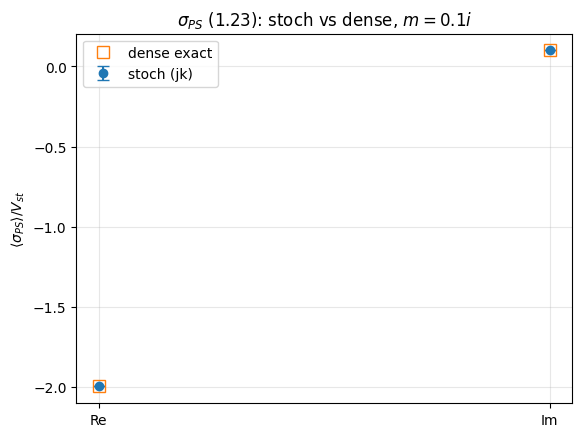

In [42]:
# sigma_PS: stoch (errorbar, Re & Im) vs dense exact (lines).  /Vst.
est, ere, eim = jk_complex(raw['sigma_PS'])
d = dense['sigma_PS']/Vst
plt.figure()
plt.errorbar([0, 1], [est.real/Vst, est.imag/Vst], yerr=[ere/Vst, eim/Vst], fmt='o', capsize=4, label='stoch (jk)')
plt.plot([0, 1], [d.real, d.imag], 's', ms=9, mfc='none', label='dense exact')
plt.xticks([0, 1], ['Re', 'Im'])
plt.ylabel(r'$\langle\sigma_{PS}\rangle / V_{st}$'); plt.title(r'$\sigma_{PS}$ (1.23): stoch vs dense, $m='+MTIT+'$')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(FIGDIR+'/condensate_sigma_PS_'+MLAB+'.pdf', bbox_inches='tight')

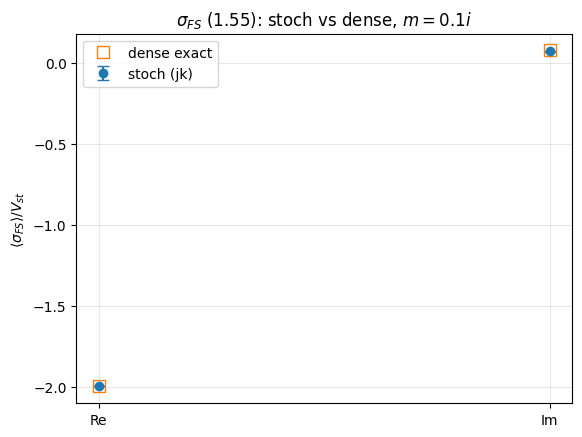

In [43]:
# sigma_FS: stoch (errorbar, Re & Im) vs dense exact (lines).  /Vst.
est, ere, eim = jk_complex(raw['sigma_FS'])
d = dense['sigma_FS']/Vst
plt.figure()
plt.errorbar([0, 1], [est.real/Vst, est.imag/Vst], yerr=[ere/Vst, eim/Vst], fmt='o', capsize=4, label='stoch (jk)')
plt.plot([0, 1], [d.real, d.imag], 's', ms=9, mfc='none', label='dense exact')
plt.xticks([0, 1], ['Re', 'Im'])
plt.ylabel(r'$\langle\sigma_{FS}\rangle / V_{st}$'); plt.title(r'$\sigma_{FS}$ (1.55): stoch vs dense, $m='+MTIT+'$')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(FIGDIR+'/condensate_sigma_FS_'+MLAB+'.pdf', bbox_inches='tight')

In [44]:
dense['sigma_FS']/Vst, dense['sigma_PS']/Vst

(np.complex128(-1.9982555219933964+0.07789442825286613j),
 np.complex128(-1.996104961052196+0.09991594644148222j))